In [10]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))
# my utils
from utils import fa
from utils import modeling
from utils import preprocess_listings

# 标准版存档V0：
LABELS_EN=[
            'open to different cultures', 'cosmopolitan','international view', 'cultural exchange',
            'personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life',
            'meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction',
            'thoughtful service', 'attentive to needs', 'willing to help', 'responsive',
            'fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb'
        ]

LABELS_FR=[ 
           'ouvert aux différentes cultures', 'cosmopolite','vue internationale', 'échange culturel',
           'vie personnelle', 'parcours personnel', 'loisirs', 'passions', 'aimer la vie',
           'rencontrer de nouvelles personnes', 'accueillant', 'amical','sociable', 'interaction interpersonnelle',
           'rendre service','attentif aux besoins', 'prêt à aider', 'réactif',
           "adepte d'Airbnb",'communauté Airbnb', 'aime Airbnb', 'voyager par Airbnb'
        ]
dict_items={'en':LABELS_EN,
            'fr':LABELS_FR}
dict_fr2en=dict(zip(LABELS_FR, LABELS_EN))
print(dict_fr2en)
        
DICT_FACTOR_ITEMS={"ouverture":['open to different cultures', 'cosmopolitan','international view', 'cultural exchange'],
                   "authenticité":['personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life'],
                   "sociabilité":['meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction'],
                   "auto_promotion":['thoughtful service', 'attentive to needs', 'willing to help', 'responsive'],
                   "exemplarité":['fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb']}


{'ouvert aux différentes cultures': 'open to different cultures', 'cosmopolite': 'cosmopolitan', 'vue internationale': 'international view', 'échange culturel': 'cultural exchange', 'vie personnelle': 'personal life', 'parcours personnel': 'life experiences', 'loisirs': 'divers interests', 'passions': 'hobbies', 'aimer la vie': 'enjoy life', 'rencontrer de nouvelles personnes': 'meet new people', 'accueillant': 'welcoming', 'amical': 'friendly', 'sociable': 'sociable', 'interaction interpersonnelle': 'interpersonal interaction', 'rendre service': 'thoughtful service', 'attentif aux besoins': 'attentive to needs', 'prêt à aider': 'willing to help', 'réactif': 'responsive', "adepte d'Airbnb": 'fan of Airbnb', 'communauté Airbnb': 'Airbnb community', 'aime Airbnb': 'love Airbnb', 'voyager par Airbnb': 'travel with Airbnb'}


# paris2312 

In [23]:
zsc_en=pd.read_csv("../data_processed_paris2312/bge_zsc_en.csv")
zsc_fr=pd.read_csv("../data_processed_paris2312/bge_zsc_fr.csv")
print(zsc_en.shape, zsc_fr.shape)
zsc_fr.rename(columns=dict_fr2en, inplace=True)

display(zsc_en.head(2))
display(zsc_fr.head(2))

(7879, 24) (12109, 24)


,id,host_about,attentive to needs,welcoming,friendly,sociable,responsive,thoughtful service,international view,interpersonal interaction,...,enjoy life,cultural exchange,divers interests,open to different cultures,travel with Airbnb,fan of Airbnb,love Airbnb,meet new people,personal life,hobbies
0,5396.0,We have spent a lot of time traveling for work...,0.995195,0.986460,0.982835,0.982809,0.973056,0.970217,0.957682,0.953720,...,0.721678,0.588577,0.508959,0.326977,0.312311,0.285508,0.137775,0.111350,0.010742,0.008257
1,81106.0,Independent photographer. \nCyclist. Often on ...,0.811337,0.806805,0.141630,0.584475,0.639749,0.706699,0.766916,0.751882,...,0.712022,0.001054,0.950056,0.270624,0.258570,0.095681,0.021362,0.011969,0.831021,0.879059


,id,host_about,welcoming,friendly,divers interests,travel with Airbnb,attentive to needs,love Airbnb,Airbnb community,thoughtful service,...,personal life,life experiences,cultural exchange,enjoy life,open to different cultures,fan of Airbnb,international view,cosmopolitan,hobbies,meet new people
0,9952,"Parisienne retraitée, dynamique et accueillant...",0.992812,0.935814,0.909193,0.875256,0.874508,0.856798,0.826970,0.748013,...,0.548789,0.462885,0.284487,0.205789,0.186578,0.152814,0.041465,0.041297,0.035062,0.031609
1,87481,Je trouve un réel plaisir à accueillir mes hôt...,0.998978,0.949157,0.913987,0.499078,0.965520,0.923180,0.980773,0.969415,...,0.969323,0.983606,0.916447,0.530114,0.372059,0.591269,0.021710,0.597080,0.790833,0.527021


In [27]:
zsc_all=pd.concat([zsc_fr, zsc_en], axis=0)
desired_order=['id', 'host_about']+LABELS_EN
zsc_all=zsc_all[desired_order]
print(zsc_all.shape)
# print(zsc_all.host_about.value_counts(dropna=False, ascending=False))
# display(zsc_all.head())
zsc_all.to_csv("../data_processed_paris2312/listings_paris2312_zsc19988.csv", index=False)



(19988, 24)


## preprocess

In [29]:
df_paris2312=pd.read_csv("../data_raw\listings_paris2312.csv")
df_paris2403=pd.read_csv("../data_raw\listings_paris2403.csv")
print(df_paris2312.shape, df_paris2403.shape)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_20116\2643633918.py:1: DtypeWarning: Columns (6,22,41,45,46,61) have mixed types. Specify dtype option on import or set low_memory=False.
  df_paris2312=pd.read_csv("../data_raw\listings_paris2312.csv")


(74330, 76) (84397, 75)


In [30]:
import os, sys, importlib, pathlib
import pandas as pd
sys.path.append(os.path.abspath(".."))
from utils import split_listings, preprocess_listings

importlib.reload(split_listings)
importlib.reload(preprocess_listings)
from utils.split_listings import split_change_stable
from utils.preprocess_listings import preprocess_host_variables, preprocess_obj_vars


##====================-split, +process===========================

path_df="../data_raw\listings_paris2312.csv"
path_nextQ="../data_raw\listings_paris2403.csv"

df=pd.read_csv(path_df)
df_nextQ=pd.read_csv(path_nextQ)
print(df.shape, df_nextQ.shape)

df_processed=preprocess_host_variables(df)
df_filtered=preprocess_obj_vars(df=df_processed, df_nextQ=df_nextQ, proxy_vars=['price',"availability_30","availability_90"], 
                        get_booking_rate_l30d=True, filtrate_by_booking_rate_l30d=False,#无输入时默认不按照booking筛选 
                        get_booking_rate_l90d=True, filtrate_by_booking_rate_l90d=True,
                        obj_vars=["room_type", 'property_type',"minimum_nights","instant_bookable"], 
                        threshold_km=1, 
                        output_folder="../data_processed_paris2312", filename=f"listings_paris2312_filtered.csv")

C:\Users\yeliu\AppData\Local\Temp\ipykernel_20116\248557345.py:17: DtypeWarning: Columns (6,22,41,45,46,61) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(path_df)


(74330, 76) (84397, 75)


******************************HOST VARS******************************
PROCESS PIPELINE :
- host_has_profile_pic : fillna('f') if not f/t
- host_identity_verified: fillna('f') if not f/t 
- host_is_sueprhost: check ONLY 't'/'f'; fillna('f')
- review_scores_rating: 24.0% NaN; fillna(mean), to numeric; ADD 'has_rating' 
- host_since: ADD 'years_since_host' :float, 0.5-1 year=>1， 0-0.5 year => 0 
- has_host_about: 'lang:en/fr/other_langs','len:int',
- host_response_time:41.0% NaN, fillna('no_response_time') 
- host_response_rate:41.0% NaN, ADD 'has_response_rate' :1/0， fillna(0)
- calculated_host_listings_count : ADD 'professional_host:1/0', count>1

[INFO] missing review scores are filled by mean :4.689369847503803

==========================HOST VARS================================
16 IMPO VARS:['host_picture_url', 'host_identity_verified', 'number_of_reviews', 'host_is_superhost', 'review_scores_rating', 'has_rating', 'host_since', 'years_since_host', 'host_abo

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\preprocess_listings.py:421: RuntimeWarning: All-NaN axis encountered
  return np.nanmin(distances) if len(distances) > 0 else np.nan


is_within_1km
0    68370
1     5960
Name: count, dtype: int64
# -----------------------filter & desc-------------------------
[INFO] vars to dropna:number_of_reviews_nextQ; minimum_nights; is_within_1km; availability_90; property_type; price; number_of_reviews_l30d; availability_30; booking_rate_l30d; booking_rate_l90d; room_type; instant_bookable
[CHECK] no filter on 'number_of_reviews_l30d','availability_30','booking_rate_l30d'!
[INFO]6668 nan dropped in number_of_reviews_nextQ
[INFO]0 nan dropped in minimum_nights
[INFO]0 nan dropped in is_within_1km
[INFO]0 nan dropped in availability_90
[INFO]0 nan dropped in property_type
[INFO]6860 nan dropped in price
[INFO]24973 nan dropped in booking_rate_l90d
[INFO]0 nan dropped in room_type
[INFO]0 nan dropped in instant_bookable

len BEFORE filtrage by number_of_reviews_nextQ; minimum_nights; is_within_1km; availability_90; property_type; price; number_of_reviews_l30d; availability_30; booking_rate_l30d; booking_rate_l90d; room_type; insta

## merge+fa:

In [ ]:
# merge
from utils import zsc
importlib.reload(zsc)
from utils.zsc import merge_by_host_about

path_df_filtered="../data_processed_paris2312\listings_paris2312_filtered.csv"
path_zsc_result="../data_processed_paris2312/listings_paris2312_zsc19988.csv"
labels_en=[
    'open to different cultures', 'cosmopolitan','international view', 'cultural exchange',
    'personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life',
    'meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction',
    'thoughtful service', 'attentive to needs', 'willing to help', 'responsive',
    'fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb'
]
print(len(labels_en))
df_items=merge_by_host_about(path_df_zsc=path_zsc_result,
            path_df_filtered=path_df_filtered,
            desired_items_order=labels_en,
            text_col="host_about",
            save=True,
            output_folder="../data_processed_paris2312",
            filename="listings_paris2312_bge_items.csv"
            )


22
[INFO] df_zsc :19988; df_filtered: 35829!
[CHECK]cols to merge :['host_about', 'open to different cultures', 'cosmopolitan', 'international view', 'cultural exchange', 'personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life', 'meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction', 'thoughtful service', 'attentive to needs', 'willing to help', 'responsive', 'fan of Airbnb', 'Airbnb community', 'love Airbnb', 'travel with Airbnb']

-------------------------------merge items scores back to df_filtered-------------------------------
[INFO] len df items : 35829
no match rows stay NaN on items cols!!
✅[SAVE] df merged with items scores saved to ../data_processed_paris2312\listings_paris2312_bge_items.csv!
 ready for fa!


[INFO] df_items : 35829 rows!
[INFO] all output saved to '../data_processed_paris2312/output_fa'!
df with fa scores saved to '../data_processed_paris2312' !
[CHECK] INITIALISE DF, or MERGE fa scores will go WRONG!!!
============================RUN FA=================================
[INFO] len scores in df notna:15866

[INFO] kmo_model score (> 0.7) :0.8694657872575208

[INFO] oblimin allows cross-loadings!

---------------------------heatmap of items-------------------------------
[INFO] good loadings > 0.5
Rename loadings df with fa_names in proper order !


d:\miniconda3\envs\airbnb_env\lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


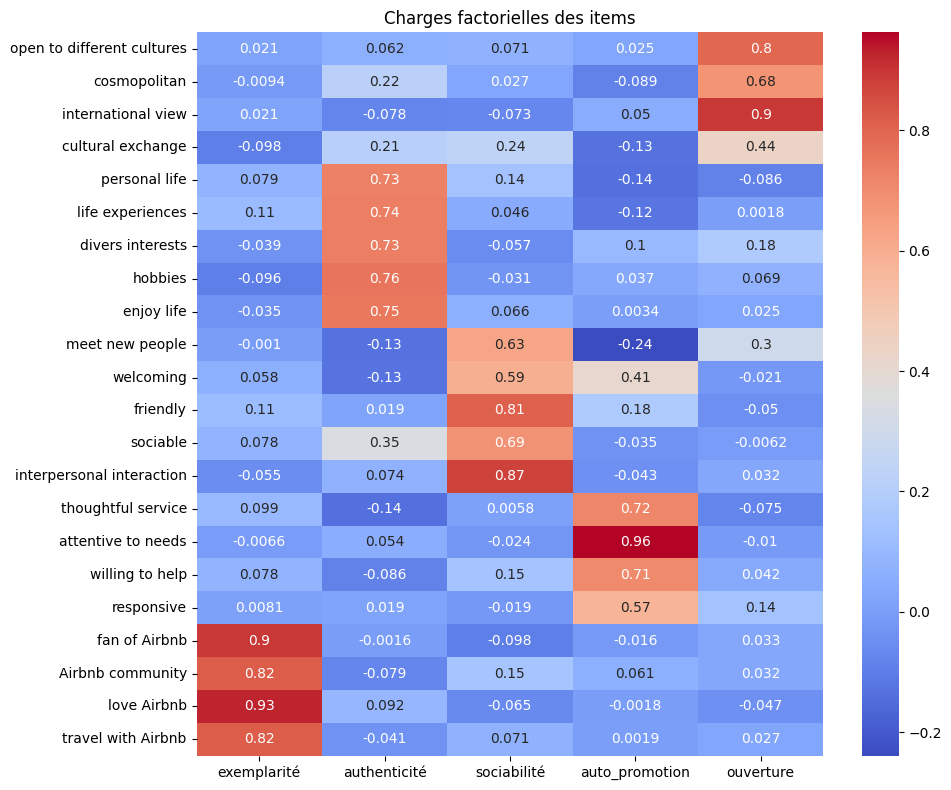

✅ [SAVE] heatmap of items saved to ../data_processed_paris2312/output_fa\heatmap_fa_items.jpeg!

----------------------------organise input FA_ITEMS_DICT as latex table-----------------------------


,Tactique,items
0,ouverture,"open to different cultures, cosmopolitan, inte..."
1,authenticité,"personal life, life experiences, divers intere..."
2,sociabilité,"meet new people, welcoming, friendly, sociable..."
3,auto_promotion,"thoughtful service, attentive to needs, willin..."
4,exemplarité,"fan of Airbnb, Airbnb community, love Airbnb, ..."


☑️[SAVE] Table saved as LaTeX to ../data_processed_paris2312/output_fa\latex\fa_items_table.tex!

# ------------------------------------tab items fa------------------------------------
[INFO] mean COMM (> 0.6):0.62923425244236
[INFO] mean UNIQ : 0.3707657475576399

[WARNING] 2/22 low communality items (< 0.5):
cultural exchange;responsive

✅ [SAVE] items fa CSV saved to ../data_processed_paris2312/output_fa\items_fa.csv!

☑️[SAVE] Table saved as LaTeX to ../data_processed_paris2312/output_fa\latex\items_fa.tex!

[CHECK] remember to RENAME factors by heatmap of zsc data!!!
=======================================get fa scores(tactics)=======================================
WEIGHTED ORDER:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
[INFO] shape df scores = 5*len(get_factor_scores_by):(15866, 5)
---------------------------------run fa on scores(must do)--------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:157: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:157: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:157: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please 

,Dimension 1,Dimension 2
ouverture,-0.213843,0.445683
authenticité,-0.418734,0.629152
sociabilité,0.276502,0.728885
auto_promotion,0.839200,-0.011174
exemplarité,0.513304,0.245685


✅[SAVE] scores df saved to ../data_processed_paris2312/output_fa\scores_fa.csv!
☑️[SAVE] Table saved as LaTeX to ../data_processed_paris2312/output_fa\latex\scores_weighted_fa.tex!



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)


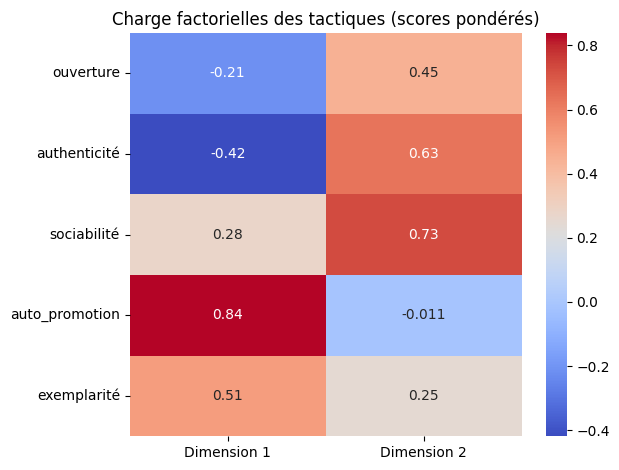

✅ [SAVE] heatmap of pondérés scores saved to ../data_processed_paris2312/output_fa\heatmap_fa_scores_weighted.jpg!

----------------------------merge data to listings(keeping nan)---------------------------------


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,responsive,fan of Airbnb,Airbnb community,love Airbnb,travel with Airbnb,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
0,3109.0,https://www.airbnb.com/rooms/3109,2.023121e+13,2023-12-12,city scrape,Rental unit in Paris · ★5.0 · 1 bedroom · 1 be...,NaN,Good restaurants<br />very close the Montparna...,https://a0.muscache.com/pictures/baeae9e2-cd53...,3631.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,81106.0,https://www.airbnb.com/rooms/81106,2.023121e+13,2023-12-13,city scrape,Rental unit in Paris · ★4.84 · 1 bedroom · 1 b...,NaN,The neighborhood will show you an other side o...,https://a0.muscache.com/pictures/miso/Hosting-...,439130.0,...,0.639749,0.095681,0.093284,0.021362,0.258570,-0.336653,1.087472,-0.489013,0.498599,-0.446364
2,7397.0,https://www.airbnb.com/rooms/7397,2.023121e+13,2023-12-13,city scrape,Rental unit in Paris · ★4.73 · 2 bedrooms · 2 ...,NaN,NaN,https://a0.muscache.com/pictures/67928287/330b...,2626.0,...,0.380097,0.000321,0.000877,0.000308,0.001214,-1.151603,-0.690868,-1.841719,-1.553996,-0.768819
3,81615.0,https://www.airbnb.com/rooms/81615,2.023121e+13,2023-12-13,city scrape,Rental unit in Paris · ★4.74 · 1 bedroom · 1 b...,NaN,NaN,https://a0.muscache.com/pictures/2630947/9340f...,429406.0,...,0.456869,0.541624,0.986274,0.281515,0.185741,0.186354,0.710815,-0.788593,-0.610560,0.947022
4,86053.0,https://www.airbnb.com/rooms/86053,2.023121e+13,2023-12-13,city scrape,Rental unit in Paris · ★4.88 · 1 bedroom · 2 b...,NaN,The flat is situated in the very heart of Pari...,https://a0.muscache.com/pictures/1982057/f94cf...,296615.0,...,0.629932,0.021728,0.766359,0.071569,0.320365,0.264013,-0.243519,1.354187,1.196126,0.160908


[INFO] scores shape (len(data), 1/2*n_factors) :(15866, 5)
len(df_dropna) should == len(df_scores)==len(df_tactics): 15866, 15866, 15866
len(DF)==len(listings_tactics):35829,35829

✅ [SAVE] listings with tactics scores by 'weighted'way saved to ../data_processed_paris2312\listings_paris2312_bge_scores.csv!!

###====================================CHECK=======================================###
---------------------------cronbach's alpha-------------------------------
[INFO] good alpha > 0.7

Cronbach's alpha checks internal consistency, whether items mesure a lantent construct !



,tactique,cronbach_alpha
0,ouverture,0.838836
1,authenticité,0.881661
2,sociabilité,0.862639
3,auto_promotion,0.844656
4,exemplarité,0.921327


✅ [SAVE] cronbach's alpha on items saved to ../data_processed_paris2312/output_fa\cronbachs_alpha.csv!



In [35]:
# fa
from utils import fa
importlib.reload(fa)
from utils.fa import run_fa


path_df_items= "../data_processed_paris2312\listings_paris2312_bge_items.csv"

run_fa(path_df_items=path_df_items, items=LABELS_EN, 
        output_folder="../data_processed_paris2312/output_fa",
        output_folder_data="../data_processed_paris2312",
        n_factors=5, rotation="oblimin",
        fa_names=["exemplarité","authenticité","sociabilité","auto_promotion","ouverture"],#check order!!
        dict_factor_items=DICT_FACTOR_ITEMS,
        get_items_heatmap=True,
        get_items_table=True, low_comm_t=0.5,
        get_factor_scores_by='weighted',
        run_fa_on_scores="weighted",
        get_scores_heatmap=True,
        get_cronbachs_a=True,
        get_barplot=False, get_pca3d=False, 
        ndigits=4)

# df_paris_all

In [64]:
# df_paris2406=pd.read_csv("../data_processed_paris\listings_paris2406_bge_scores.csv")
print(df_paris2406.shape)
print(df_paris2406.columns.to_list())
display(df_paris2406[['status_changed','old_host_sp_changed','is_changed']].head())

(62738, 128)
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_90

,status_changed,old_host_sp_changed,is_changed
0,0,0,0
1,1,0,1
2,0,0,0
3,0,0,0
4,1,0,1


In [81]:
# df_paris2312=pd.read_csv("../data_processed_paris2312\listings_paris2312_bge_scores.csv")
# df_paris2406=pd.read_csv("../data_processed_paris\listings_paris2406_bge_scores.csv")
print(df_paris2312.shape, df_paris2406.shape)

df_paris2312['ym']="2312"
df_paris2406['ym']='2406'

df_paris2312['city']="paris"
df_paris2406['city']='paris'


df_paris2312['is_new_entrant']=0
df_paris2406['is_new_entrant']=df_paris2406.apply(lambda row : 1 if row["status_changed"]==1 else 0, axis=1)

df_paris2312['is_changed']=0
df_paris2312['old_host_sp_changed']=0
df_paris2312['status']="old_host"

# display(df_paris2312['ym'].head())

(35829, 119) (62738, 131)


In [82]:
vars_comm=[x for x in df_paris2406.columns.to_list() if x in df_paris2312.columns.to_list() ]
print(vars_comm)
print(len(vars_comm))
df_paris2312_comm=df_paris2312[vars_comm]
df_paris2406_comm=df_paris2406[vars_comm]

df_paris_all=pd.concat([df_paris2312_comm, df_paris2406_comm], axis=0)
print(df_paris_all.shape)
display(df_paris_all.head())
# df_paris_all.to_csv("../data_all\listings_paris2324.csv",index=False)


['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availabil

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,love Airbnb,travel with Airbnb,ouverture,authenticité,sociabilité,auto_promotion,exemplarité,ym,is_new_entrant,city
0,3109.0,https://www.airbnb.com/rooms/3109,2.023121e+13,2023-12-12,city scrape,Rental unit in Paris · ★5.0 · 1 bedroom · 1 be...,NaN,Good restaurants<br />very close the Montparna...,https://a0.muscache.com/pictures/baeae9e2-cd53...,3631.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2312,0,paris
1,81106.0,https://www.airbnb.com/rooms/81106,2.023121e+13,2023-12-13,city scrape,Rental unit in Paris · ★4.84 · 1 bedroom · 1 b...,NaN,The neighborhood will show you an other side o...,https://a0.muscache.com/pictures/miso/Hosting-...,439130.0,...,0.021362,0.258570,-0.336653,1.087472,-0.489013,0.498599,-0.446364,2312,0,paris
2,7397.0,https://www.airbnb.com/rooms/7397,2.023121e+13,2023-12-13,city scrape,Rental unit in Paris · ★4.73 · 2 bedrooms · 2 ...,NaN,NaN,https://a0.muscache.com/pictures/67928287/330b...,2626.0,...,0.000308,0.001214,-1.151603,-0.690868,-1.841719,-1.553996,-0.768819,2312,0,paris
3,81615.0,https://www.airbnb.com/rooms/81615,2.023121e+13,2023-12-13,city scrape,Rental unit in Paris · ★4.74 · 1 bedroom · 1 b...,NaN,NaN,https://a0.muscache.com/pictures/2630947/9340f...,429406.0,...,0.281515,0.185741,0.186354,0.710815,-0.788593,-0.610560,0.947022,2312,0,paris
4,86053.0,https://www.airbnb.com/rooms/86053,2.023121e+13,2023-12-13,city scrape,Rental unit in Paris · ★4.88 · 1 bedroom · 2 b...,NaN,The flat is situated in the very heart of Pari...,https://a0.muscache.com/pictures/1982057/f94cf...,296615.0,...,0.071569,0.320365,0.264013,-0.243519,1.354187,1.196126,0.160908,2312,0,paris


In [85]:
print(df_paris_all['is_new_entrant'].value_counts(dropna=False))# status_changed2406+2312
print(df_paris_all['is_changed'].value_counts(dropna=False))# is_changed2406+2312
print(df_paris_all['old_host_sp_changed'].value_counts(dropna=False))
print(df_paris_all['status'].value_counts(dropna=False))# old_host2406+2312

is_new_entrant
0    75748
1    22819
Name: count, dtype: int64
is_changed
0    69470
1    29097
Name: count, dtype: int64
old_host_sp_changed
0    92289
1     6278
Name: count, dtype: int64
status
old_host         75748
reopen_host      11665
reactive_host     8999
new_host          2155
Name: count, dtype: int64


# desc & modeling

In [70]:
importlib.reload(preprocess_listings)
from utils.preprocess_listings import group_mean_table_ttest
OUTPUT_FOLDER_DESC=Path("../output_desc")
os.makedirs(OUTPUT_FOLDER_DESC, exist_ok=True)

cols_to_check=[
    # "host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating",'number_of_reviews',
    "years_since_host", "professional_host",#'calculated_host_listings_count',
    # "lang", "len",
    "price", "availability_30","availability_90", "room_type", "instant_bookable",
    "number_of_reviews_thisQ", "number_of_reviews_nextQ",
    "booking_rate_l90d_previousQ", "booking_rate_l90d",
]   
tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]

group_mean_table_ttest(df=df_paris_all, #*
            cols_to_check=cols_to_check+tactics_vars, 
            group_col='ym', #*
            save=False, output_folder=OUTPUT_FOLDER_DESC, filename_noext=None)

[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :2312 vs 2406
[INFO] ttest on 98567 lines.

[WARNING]3 missing cols in df_input :
 number_of_reviews; number_of_reviews_thisQ; booking_rate_l90d_previousQ

[CHECK] ttest take ONLY numeric cols! 

[WARNING] no numeric cols:
 room_type; instant_bookable



ym,2312,2406,ttest_p,significance
proportion,0.363499,0.636501,NaN,NaN
review_scores_rating,4.739183,4.771447,0.0,***
years_since_host,7.147199,6.836622,0.0,***
professional_host,0.404002,0.344257,0.0,***
price,231.362862,283.362731,0.0,***
availability_30,14.315275,11.124853,0.0,***
availability_90,49.523012,49.923236,0.039469,*
number_of_reviews_nextQ,2.312177,2.317352,0.851928,
booking_rate_l90d,0.10237,0.076108,0.0,***
ouverture,-0.0,-0.0,1.0,


In [77]:
group_mean_table_ttest(df=df_paris_all, #*
            cols_to_check=cols_to_check+tactics_vars, 
            group_col='is_new_entrant', #*
            save=False, output_folder=OUTPUT_FOLDER_DESC, filename_noext=None)

[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :0 vs 1
[INFO] ttest on 98567 lines.

[WARNING]3 missing cols in df_input :
 number_of_reviews; number_of_reviews_thisQ; booking_rate_l90d_previousQ

[CHECK] ttest take ONLY numeric cols! 

[WARNING] no numeric cols:
 room_type; instant_bookable



is_new_entrant,0,1,ttest_p,significance
proportion,0.768492,0.231508,NaN,NaN
review_scores_rating,4.74562,4.806522,0.0,***
years_since_host,6.999868,6.782374,0.0,***
professional_host,0.432209,0.146106,0.0,***
price,250.969108,309.246812,0.0,***
availability_30,13.727914,7.493361,0.0,***
availability_90,51.696388,43.408826,0.0,***
number_of_reviews_nextQ,2.534588,1.588106,0.0,***
booking_rate_l90d,0.093599,0.059282,0.0,***
ouverture,-0.012409,0.052236,0.0,***


In [ ]:
df_paris_=df_paris_all[df_paris_all['status']!="reopen_host"]# 进比较new host+old_host
group_mean_table_ttest(df=df_paris_all, #*
            cols_to_check=cols_to_check+tactics_vars, 
            group_col='is_new_entrant', #*
            save=False, output_folder=OUTPUT_FOLDER_DESC, filename_noext=None)

[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :0 vs 1
[INFO] ttest on 98567 lines.

[WARNING]3 missing cols in df_input :
 number_of_reviews; number_of_reviews_thisQ; booking_rate_l90d_previousQ

[CHECK] ttest take ONLY numeric cols! 

[WARNING] no numeric cols:
 room_type; instant_bookable



is_new_entrant,0,1,ttest_p,significance
proportion,0.768492,0.231508,NaN,NaN
review_scores_rating,4.74562,4.806522,0.0,***
years_since_host,6.999868,6.782374,0.0,***
professional_host,0.432209,0.146106,0.0,***
price,250.969108,309.246812,0.0,***
availability_30,13.727914,7.493361,0.0,***
availability_90,51.696388,43.408826,0.0,***
number_of_reviews_nextQ,2.534588,1.588106,0.0,***
booking_rate_l90d,0.093599,0.059282,0.0,***
ouverture,-0.012409,0.052236,0.0,***


In [88]:
df_paris_=df_paris_all[(df_paris_all['status']!="reopen_host")&(df_paris_all['old_host_sp_changed']==0)]# 进比较new host+old_host
group_mean_table_ttest(df=df_paris_all, #*
            cols_to_check=cols_to_check+tactics_vars, 
            group_col='is_new_entrant', #*
            save=False, output_folder=OUTPUT_FOLDER_DESC, filename_noext=None)

[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :0 vs 1
[INFO] ttest on 98567 lines.

[WARNING]3 missing cols in df_input :
 number_of_reviews; number_of_reviews_thisQ; booking_rate_l90d_previousQ

[CHECK] ttest take ONLY numeric cols! 

[WARNING] no numeric cols:
 room_type; instant_bookable



is_new_entrant,0,1,ttest_p,significance
proportion,0.768492,0.231508,NaN,NaN
review_scores_rating,4.74562,4.806522,0.0,***
years_since_host,6.999868,6.782374,0.0,***
professional_host,0.432209,0.146106,0.0,***
price,250.969108,309.246812,0.0,***
availability_30,13.727914,7.493361,0.0,***
availability_90,51.696388,43.408826,0.0,***
number_of_reviews_nextQ,2.534588,1.588106,0.0,***
booking_rate_l90d,0.093599,0.059282,0.0,***
ouverture,-0.012409,0.052236,0.0,***


In [89]:
group_mean_table_ttest(df=df_paris_all, #*
            cols_to_check=cols_to_check+tactics_vars, 
            group_col='old_host_sp_changed', #*
            save=False, output_folder=OUTPUT_FOLDER_DESC, filename_noext=None)

## old_host_sp_changed没有像status_changed一样尤其关注出来autopromotion？

[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :0 vs 1
[INFO] ttest on 98567 lines.

[WARNING]3 missing cols in df_input :
 number_of_reviews; number_of_reviews_thisQ; booking_rate_l90d_previousQ

[CHECK] ttest take ONLY numeric cols! 

[WARNING] no numeric cols:
 room_type; instant_bookable



old_host_sp_changed,0,1,ttest_p,significance
proportion,0.936307,0.063693,NaN,NaN
review_scores_rating,4.761872,4.728076,0.0,***
years_since_host,7.02983,5.768875,0.0,***
professional_host,0.336324,0.801848,0.0,***
price,259.243431,341.158649,0.0,***
availability_30,12.220579,13.225231,0.0,***
availability_90,49.353596,56.013061,0.0,***
number_of_reviews_nextQ,2.27597,2.896145,0.0,***
booking_rate_l90d,0.086557,0.072381,0.0,***
ouverture,0.009505,-0.103435,0.0,***


In [ ]:
df_=df_paris2406[df_paris2406["stauts_changed"]==0]
group_mean_table_ttest(df=df_, #*
            cols_to_check=cols_to_check+tactics_vars, 
            group_col='old_host_sp_changed', #*
            save=False, output_folder=OUTPUT_FOLDER_DESC, filename_noext=None)


KeyError: 'stauts_changed'

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:12, x_vars_ctrl:12
['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable', 'booking_rate_l90d']
-key_vars ; - group_cols
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(roo

,host_is_superhost,ouverture,is_base,coef,se,t,pval,sig
0,f,1,True,-0.005737,0.002228,-2.574946,0.01003,*
1,t,1,False,-0.003919,0.003396,-1.153996,0.24851,


authenticité


,host_is_superhost,authenticité,is_base,coef,se,t,pval,sig
0,f,1,True,0.007645,0.002426,3.151178,0.001627,**
1,t,1,False,0.005476,0.003857,1.419797,0.155675,


sociabilité


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:984: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


+key_vars ; - group_cols
remove key_vars in x_vars
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:984: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


+key_vars ; - group_cols
remove key_vars in x_vars
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:984: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


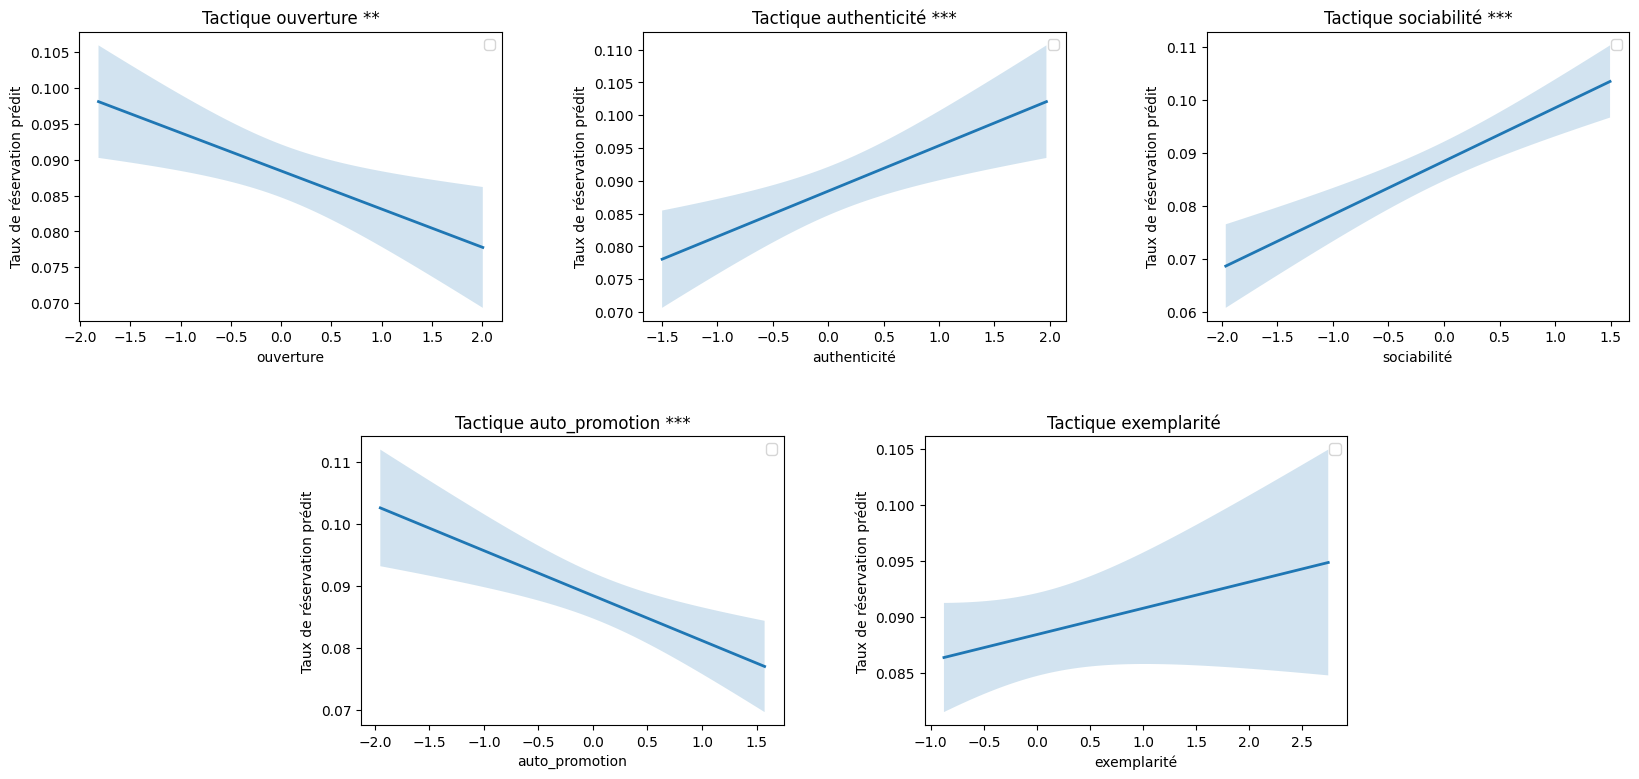

=========================================interaction plots==========================================
+key_vars ; + group_cols
remove key_vars in x_vars
LIST group_col:['host_is_superhost']
remove group_col in x_vars
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

group col str:  C(host_is_superhost)*
key_vars_f: ouverture + authenticité + sociabilité + auto_promotion + exemplarité + C(host_is_superhost)* (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité + C(host_is_superhost)* (ouverture + authenticité + so

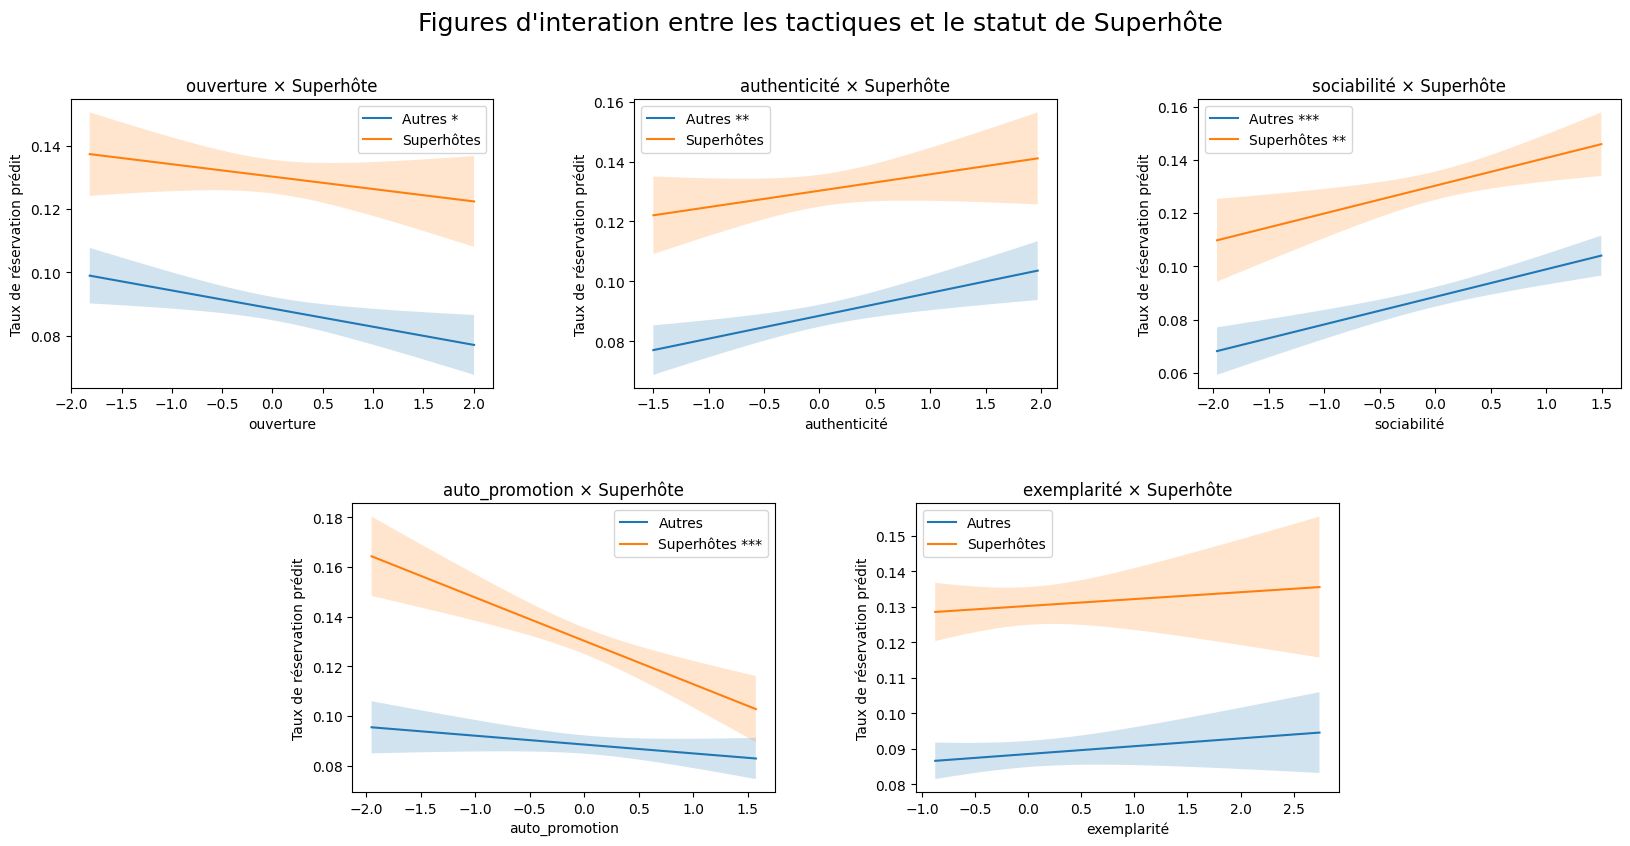

In [79]:
# 2312
from utils import modeling
importlib.reload(modeling)
from utils.modeling import modeling_main,build_model

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',"is_changed",
    # "city",
    "lang", "len",
    "price", 
    "availability_90","room_type", "instant_bookable", #'is_within_1km'
]  

tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité",
              ]

modeling_main(df_input=df_paris2312, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col='host_is_superhost',
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )


=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:13, x_vars_ctrl:13
['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'ym', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable', 'booking_rate_l90d']
-key_vars ; - group_cols
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'ym', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(y

,host_is_superhost,ouverture,is_base,coef,se,t,pval,sig
0,f,1,True,-0.004508,0.001172,-3.847964,0.000119,***
1,t,1,False,-0.006677,0.001877,-3.557369,0.000375,***


authenticité


,host_is_superhost,authenticité,is_base,coef,se,t,pval,sig
0,f,1,True,0.004784,0.001297,3.687510,0.000227,***
1,t,1,False,0.006081,0.002098,2.898291,0.003753,**


sociabilité


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:984: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


+key_vars ; - group_cols
remove key_vars in x_vars
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'ym', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(ym) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:984: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


+key_vars ; - group_cols
remove key_vars in x_vars
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'ym', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(ym) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:984: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


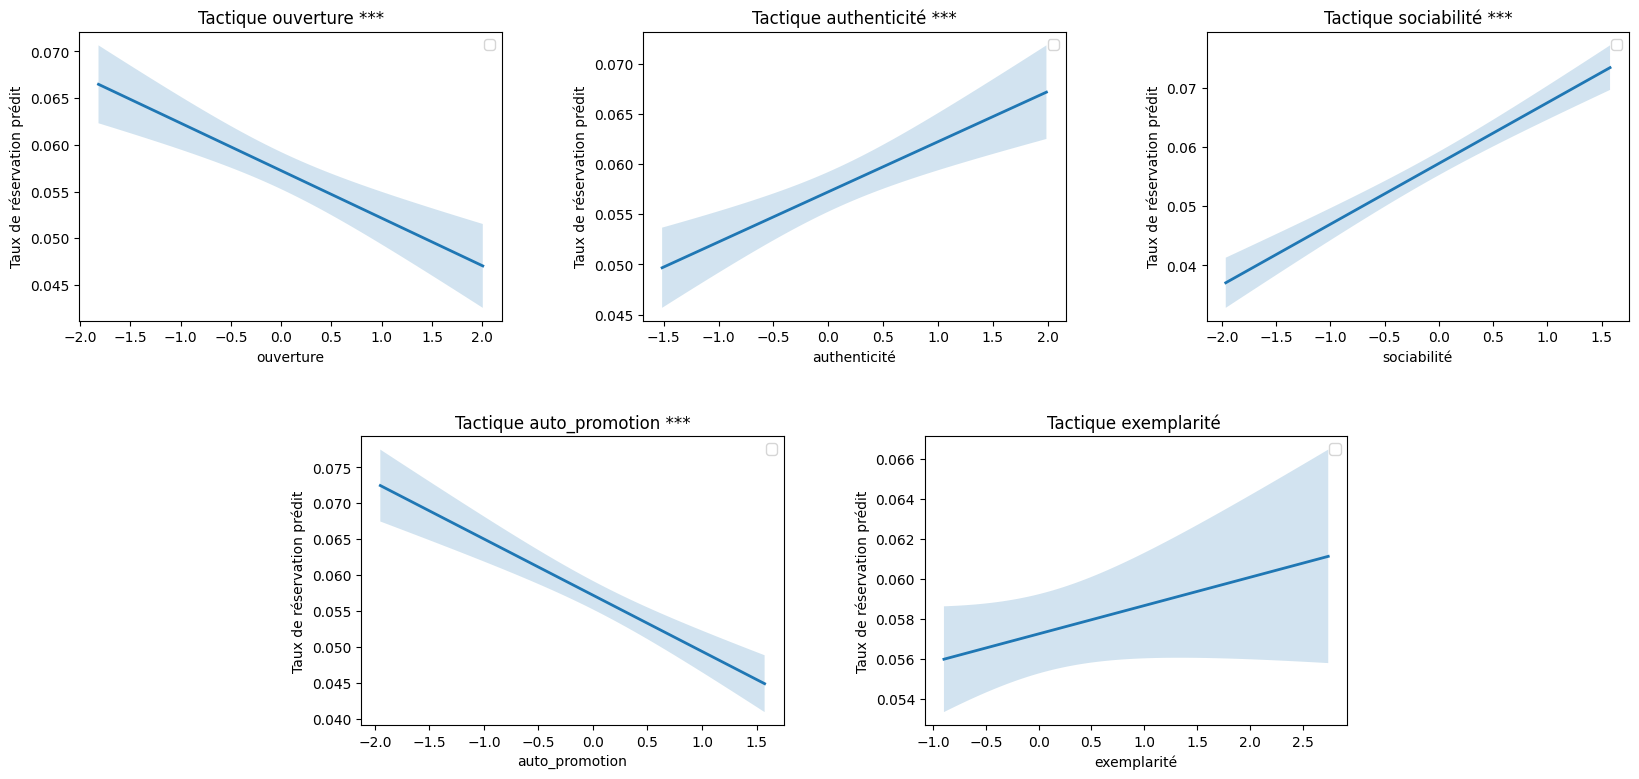

=========================================interaction plots==========================================
+key_vars ; + group_cols
remove key_vars in x_vars
LIST group_col:['host_is_superhost']
remove group_col in x_vars
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'ym', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable']

group col str:  C(host_is_superhost)*
key_vars_f: ouverture + authenticité + sociabilité + auto_promotion + exemplarité + C(host_is_superhost)* (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(ym) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité + C(host_is_superhost)* (ouverture + aut

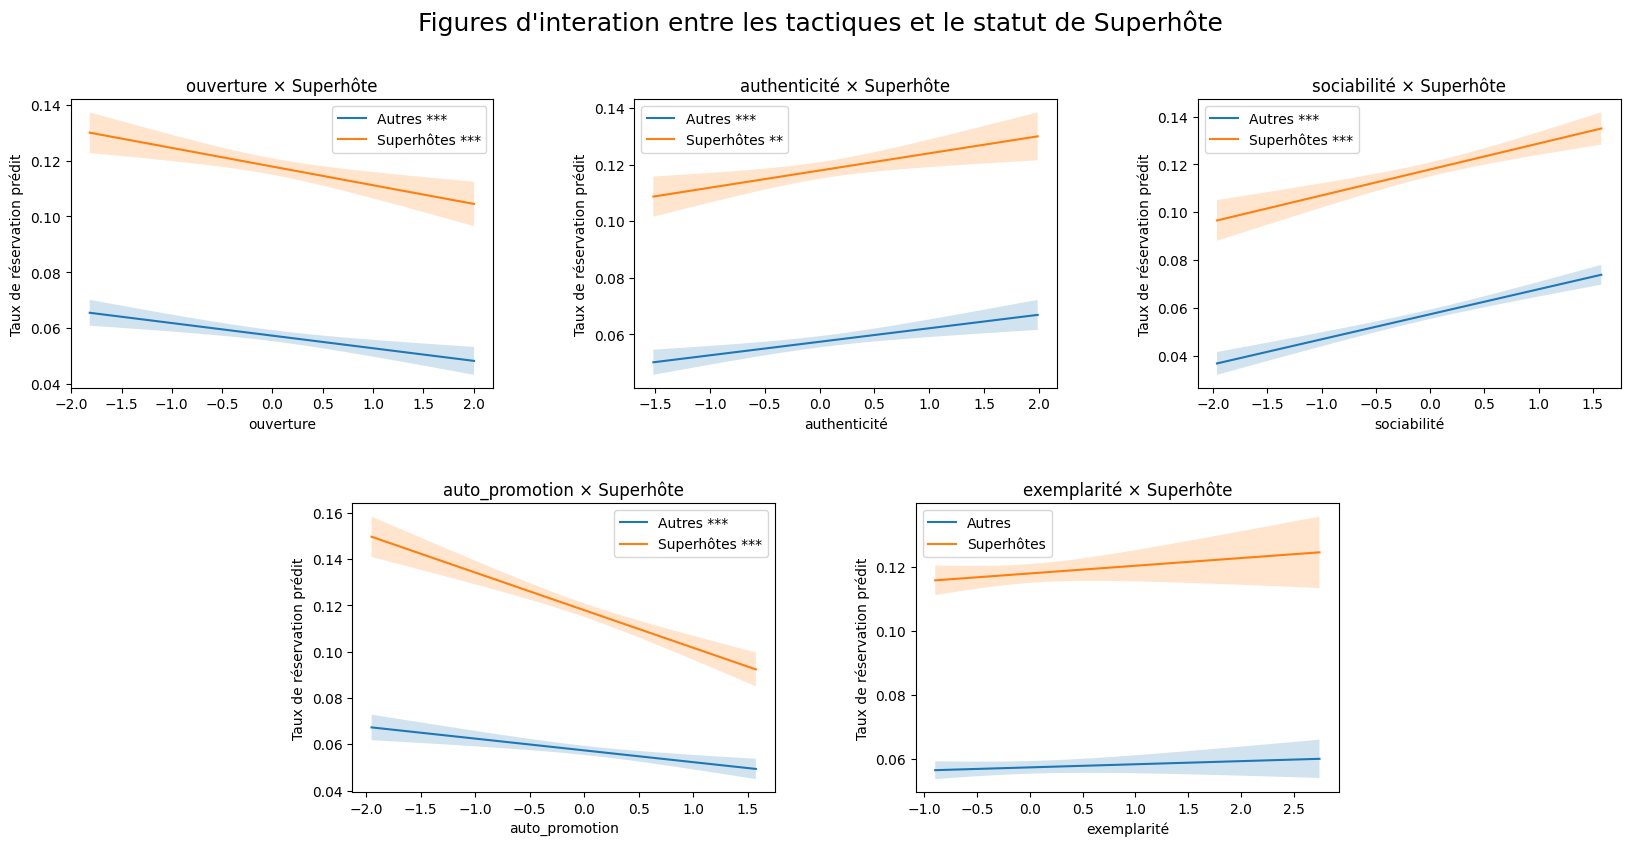

In [91]:
x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',"is_changed",
    "ym",# "city",
    "lang", "len",
    "price", 
    "availability_90","room_type", "instant_bookable", #'is_within_1km'
]  

tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité",
            #   'host_is_superhost'
              ]

modeling_main(df_input=df_paris_all, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col='host_is_superhost',#==jo
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )


In [ ]:
# ym之间没有明显差异??